<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/attention__unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import PIL

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

class MaskTransform:
    def __call__(self, target):
        target = target.resize((128, 128), PIL.Image.NEAREST)
        target = torch.as_tensor(np.array(target), dtype=torch.long)
        return target - 1

# 75 train 25 val
full_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="segmentation",
    download=True, transform=transform, target_transform=MaskTransform()
)

small_dataset = Subset(full_dataset, range(200))
train_size = int(0.75 * len(small_dataset))
val_size = len(small_dataset) - train_size

train_sub, val_sub = random_split(small_dataset, [train_size, val_size])

train_loader = DataLoader(train_sub, batch_size=8, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=8, shuffle=False)

print(f"Dataset Split: {len(train_sub)} Training images, {len(val_sub)} Validation images.")

Using device: cpu


100%|██████████| 792M/792M [00:24<00:00, 32.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 19.1MB/s]


Dataset Split: 150 Training images, 50 Validation images.


In [2]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=3):
        super().__init__()
        # Encoder (Downsampling)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # decoder + attention
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att1 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att2 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att4 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.conv4 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        g1 = self.up1(x5)
        x4_att = self.att1(g=g1, x=x4)
        d1 = self.conv1(torch.cat([x4_att, g1], dim=1))

        g2 = self.up2(d1)
        x3_att = self.att2(g=g2, x=x3)
        d2 = self.conv2(torch.cat([x3_att, g2], dim=1))

        g3 = self.up3(d2)
        x2_att = self.att3(g=g3, x=x2)
        d3 = self.conv3(torch.cat([x2_att, g3], dim=1))

        g4 = self.up4(d3)
        x1_att = self.att4(g=g4, x=x1)
        d4 = self.conv4(torch.cat([x1_att, g4], dim=1))

        return self.outc(d4)

In [3]:
def get_metrics(preds, labels, num_classes=3):

    ious = []
    dices = []

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (labels == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = pred_inds.sum().item() + target_inds.sum().item() - intersection

        # iou
        if union > 0:
            ious.append(intersection / union)

        # dice
        dice_denom = pred_inds.sum().item() + target_inds.sum().item()
        if dice_denom > 0:
            dices.append((2. * intersection) / dice_denom)
        elif dice_denom == 0:
            dices.append(1.0)

    return np.mean(ious), np.mean(dices)

Epoch 1/10 | Loss: 0.887 | Val mIoU: 0.166 | Val Dice: 0.264
Epoch 2/10 | Loss: 0.718 | Val mIoU: 0.375 | Val Dice: 0.478
Epoch 3/10 | Loss: 0.647 | Val mIoU: 0.449 | Val Dice: 0.576
Epoch 4/10 | Loss: 0.606 | Val mIoU: 0.485 | Val Dice: 0.620
Epoch 5/10 | Loss: 0.589 | Val mIoU: 0.493 | Val Dice: 0.621
Epoch 6/10 | Loss: 0.581 | Val mIoU: 0.488 | Val Dice: 0.620
Epoch 7/10 | Loss: 0.558 | Val mIoU: 0.484 | Val Dice: 0.625
Epoch 8/10 | Loss: 0.520 | Val mIoU: 0.506 | Val Dice: 0.645
Epoch 9/10 | Loss: 0.512 | Val mIoU: 0.499 | Val Dice: 0.621
Epoch 10/10 | Loss: 0.482 | Val mIoU: 0.545 | Val Dice: 0.684


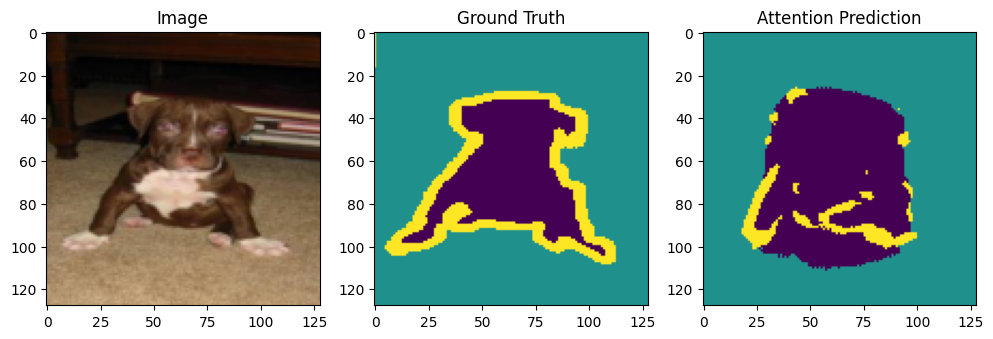

In [4]:
model = AttentionUNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss, train_iou, train_dice = 0, 0, 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        miou, dice = get_metrics(preds, masks)
        train_iou += miou
        train_dice += dice


    model.eval()
    val_loss, val_iou, val_dice = 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks).item()

            preds = torch.argmax(outputs, dim=1)
            miou, dice = get_metrics(preds, masks)
            val_iou += miou
            val_dice += dice

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {train_loss/len(train_loader):.3f} | "
          f"Val mIoU: {val_iou/len(val_loader):.3f} | "
          f"Val Dice: {val_dice/len(val_loader):.3f}")


model.eval()
with torch.no_grad():
    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    preds = torch.argmax(model(images), dim=1)

    img, true, pred = images[0].cpu().permute(1,2,0), masks[0].cpu(), preds[0].cpu()

    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(img); ax[0].set_title("Image")
    ax[1].imshow(true); ax[1].set_title("Ground Truth")
    ax[2].imshow(pred); ax[2].set_title("Attention Prediction")
    plt.show()